# Basic signals
Nesta atividades criaremos a nossa primeira **biblioteca de sinais digitais** com os sinais:

1. Delta: $\delta[n]$
2. Degrau: $u[n]$
3. Oscilação (periódico): $A \sin(\omega n + \phi)$
4. Exponencial
5. Aleatório (estocástico)


## Sinal delta, ou "impulso" - $\delta[n]$

<div style="text-align: center;">
    <img src="./figures/delta.png" alt="" width="500"/>
</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

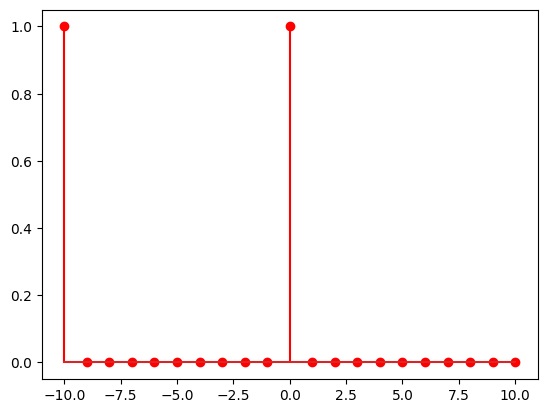

In [31]:
# 1. Sinal delta (v1.0) - Usando numpy
n     = np.arange(-10, 11)
N = len(n)
xn = np.zeros(N)
k = 0
xn[k] = 1 #

# v2.0 - Usando listas
xn    = [1 if sample == 0 else 0 for sample in n]
xn[k] = 1
xn    = np.array(xn)

# Vetor de amostras
n     = np.arange(-10, 11)

fig, ax = plt.subplots()
ax.stem(n, xn, 'r')
plt.show()

## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


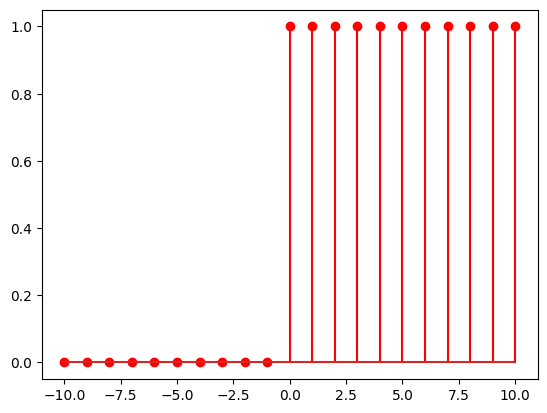

In [32]:
# 2. Degrau (v1.0) - Usando numpy
n  = np.arange(-10, 11)
un = np.zeros_like(n)
un[n >= 0] = 1

# v2.0 - Usando listas
un = [1 if sample >= 0 else 0 for sample in n]
un = np.array(un)

# Vetor de amostras
n  = np.arange(-10, 11)

fig, ax = plt.subplots()
ax.stem(n, un, 'r')
plt.show()

## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


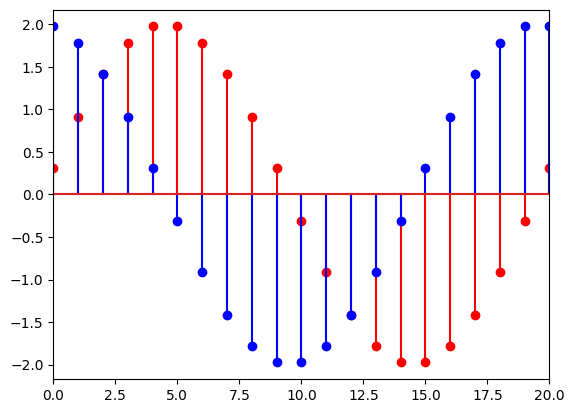

In [12]:
# 4. Sinal periodico
N  = 200 # numero de amostras
k  = 0 # delay
n  = np.arange(N) # vetor de amostras

A   = 2.0
P   = 20 # periodo do sinal
wo  = 2 * np.pi / P  # frequencia digital
phi = np.pi / P  # fase
xn  = A * np.sin(wo * n + phi)
yn  = A * np.cos(wo * n + phi)  # + 3*np.pi/2)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro')
ax.stem(n, yn, 'bd')
plt.xlim([0, 20])
plt.show()

## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


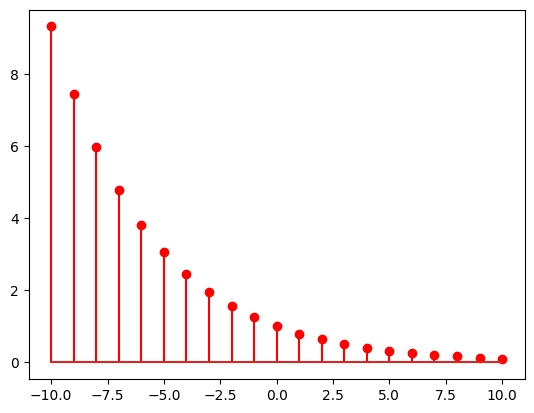

In [15]:
# 3. Exponencial
a  = 0.8
yn = a ** n

fig, ax = plt.subplots()
ax.stem(n, yn, 'r')

plt.show()

## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


### Aleatório Gaussiano - $\mathcal{X} \sim \mathcal{N}(\mu, \sigma)$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>
</div>


In [59]:
help(np.random.randn)

Help on method randn in module numpy.random:

randn(*args) method of numpy.random.mtrand.RandomState instance
    randn(d0, d1, ..., dn)

    Return a sample (or samples) from the "standard normal" distribution.

    .. note::
        This is a convenience function for users porting code from Matlab,
        and wraps `standard_normal`. That function takes a
        tuple to specify the size of the output, which is consistent with
        other NumPy functions like `numpy.zeros` and `numpy.ones`.

    .. note::
        New code should use the
        `~numpy.random.Generator.standard_normal`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.

    If positive int_like arguments are provided, `randn` generates an array
    of shape ``(d0, d1, ..., dn)``, filled
    with random floats sampled from a univariate "normal" (Gaussian)
    distribution of mean 0 and variance 1. A single float randomly sampled
    from the distributi

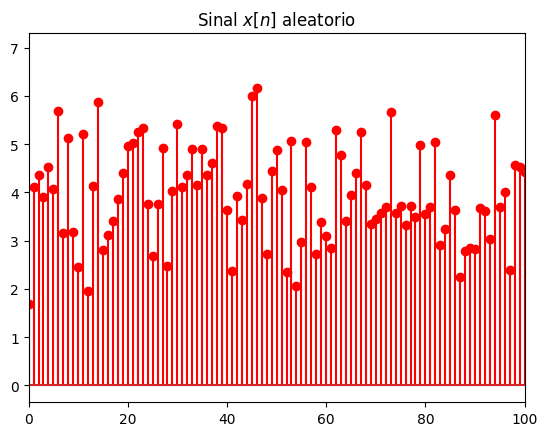

In [62]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N = 1000
n  = np.arange(N) # vetor de amostras

xn = np.random.normal(4, 1, N) # Gaussiano (normal)

#np.random.normal
# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


In [ ]:
help(ax.hist)

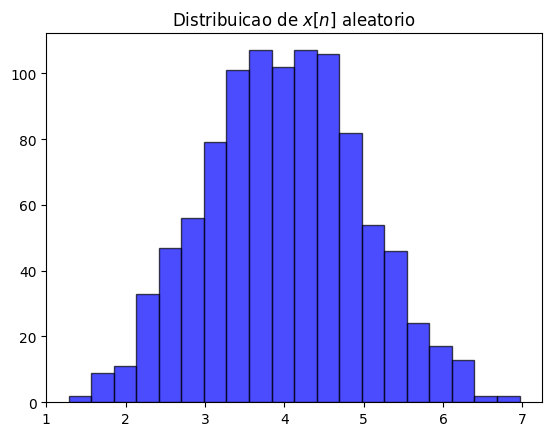

In [63]:
fig, ax = plt.subplots()
ax.hist(xn, bins=20, color='b', alpha=0.7, edgecolor='black')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
plt.show()

### Aleatório uniforme - $\mathcal{X} \sim \mathcal{U} \{a, b\}$

<div style="text-align: center;">
    <img src="./figures/random-uniform-dist.png" alt="" width="500"/>
</div>


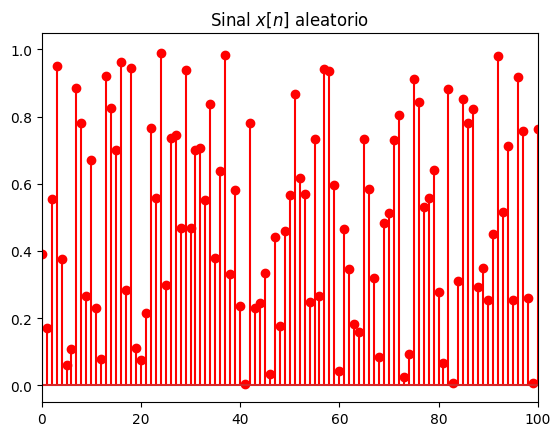

In [65]:
# 5. Sinal aleatorio (distribuicao uniforme)
N = 1000
n  = np.arange(N) # vetor de amostras

xn = np.random.uniform(0, 1, N) # uniforme

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
plt.show()

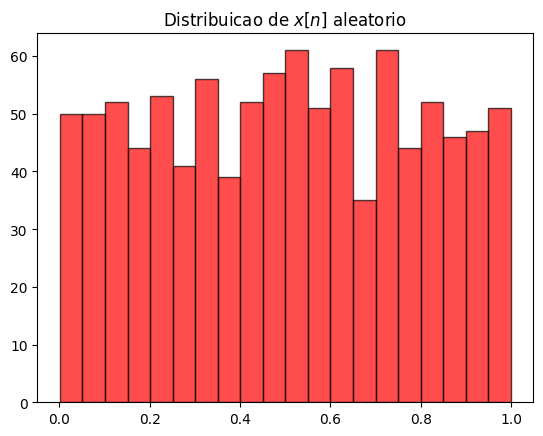

In [66]:
fig, ax = plt.subplots()
ax.hist(xn, bins=20, color='r', alpha=0.7, edgecolor='black')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
plt.show()

## Minha biblioteca de sinais básicos

In [24]:
def SIGNALgenerate(N=100, signal='delta', params=None):
    n = np.arange(N)
    if signal == 'delta':
        '''
        Delta (impulse)
        '''
        x = np.zeros(N)
        x[0] = 1

    if signal == 'step':
        '''
        Step
        '''
        x = np.ones(N)

    if signal == 'exp':
        '''
        Exponential
          - a: coefficient of exponential
        '''
        a = 0.8
        x = a ** n 

    if signal == 'osc':
        '''
        Oscillation
          - P: Period
          - phi: Phase
        '''
        P = params.get('P', 10) if params else 10
        phi = params.get('phi', 0) if params else 0
        A = params.get('A', 1) if params else 1
        wo = 2 * np.pi / P
        x = A * np.sin(wo * n + phi)  # ← Seno com amplitude, frequência e fase

    if signal == 'random':
        '''
        Random
        '''
        if params == 'uniform':
            '''
            Uniform
            '''
            x = np.random.uniform(0, 1, N)
        else:
            '''
            Gaussian
            '''
            x = np.random.randn(N)  
    return n, x

In [25]:
def SIGNALdelay(x, n):
    '''
    Slows a signal down by k samples
    '''
    
    result = np.zeros_like(x)
    result[n:] = x[:-n]
    
    return result


In [43]:
def SIGNALplot2(x):
    n = np.arange(len(x))
    fig, ax = plt.subplots()
    ax.stem(n, x, linefmt='r-', markerfmt='ro', basefmt='k-')
    plt.show()


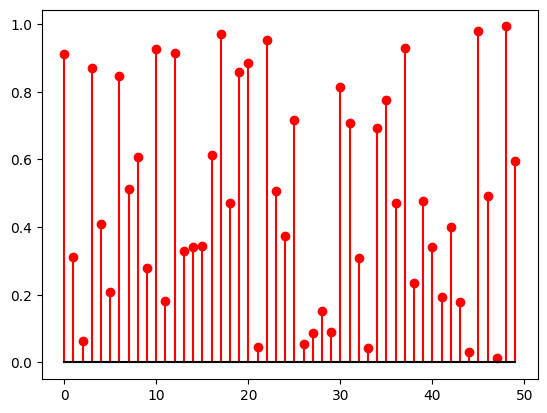

In [44]:
# Testando a biblioteca
n, x = SIGNALgenerate(50, 'random', 'uniform')
SIGNALplot2(x)
